In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 05 consolidation — Choose the object before counting its holes

Read `sessions/05_session.md` first. This is an executed reference, not an assessment of you.

**Evidence:** Real training digit foreground; exact ring and diagonal-pair controls.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
import numpy as np

ROOT = Path.cwd().resolve()
while not (ROOT/'data/raw/iris.csv').is_file():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('Start Jupyter in the extracted listening_to_shape_lab folder.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'src'))


## Step 1

Check three declared square-cell objects using connectivity and Euler counting, without boundary matrices.

Before running: write your expected result and name one way this check could fail.

In [3]:
from shape_lab.audits import pixel_betti_oracle
ring = np.ones((3, 3), dtype=bool); ring[1, 1] = False
print('ring:', pixel_betti_oracle(ring))
print('diagonal pair:', pixel_betti_oracle(np.eye(2, dtype=bool)))
assert pixel_betti_oracle(ring) == (1, 1)
assert pixel_betti_oracle(np.eye(2, dtype=bool)) == (1, 0)

ring: (1, 1)
diagonal pair: (1, 0)


## Step 2

Construct the declared foreground from one real training digit.

Before running: write your expected result and name one way this check could fail.

record: 8 threshold: 8 Betti: (1, 2)


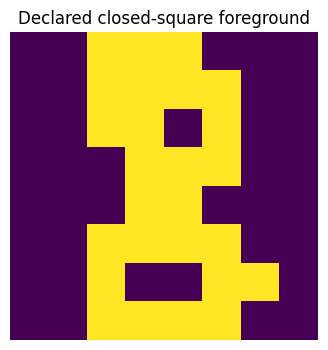

In [4]:
from shape_lab.data import digit_example
image, sample_id = digit_example(8)
threshold = 8
foreground = image >= threshold
b0, b1 = pixel_betti_oracle(foreground)
print('record:', sample_id, 'threshold:', threshold, 'Betti:', (b0, b1))
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4)); plt.imshow(foreground)
plt.title('Declared closed-square foreground'); plt.axis('off'); plt.show()

## Step 3

Record conventions next to the numeric answer.

Before running: write your expected result and name one way this check could fail.

In [5]:
result = {'sample_id': sample_id, 'foreground_rule': 'intensity >= 8',
          'object': 'union of closed square cells', 'corner_touching_connected': True,
          'betti': [b0, b1], 'claim': 'One thresholded image, not an ideal numeral.'}

## Keep execution evidence separate from learning evidence

The following saves this reference calculation. Write your own explanation in `my_work/`; no learner score is assigned.

In [6]:
result['stage'] = 5
result['execution_role'] = 'reference_consolidation'
result['data_role'] = 'Real training digit foreground; exact ring and diagonal-pair controls.'
output = ROOT/'reports/consolidation_v4/05.json'
output.parent.mkdir(parents=True, exist_ok=True)
output.write_text(json.dumps(result, indent=2, allow_nan=False) + '\n')
print('Saved reference result:', output.relative_to(ROOT))


Saved reference result: reports/consolidation_v4/05.json
